# Double Exponential Smoothing
---------------------------


# 🔴 Model
The general idea behind exponential smoothing models is that each component (here the level and the trend, and later the seasonality as well) will be updated at each period based on two pieces of information.

1. the **the most recent observation** of this component;
2. the **previous estimation** of this component.

Remember that for the simple exponential smoothing model, we updated the forecast at each period partially based on the previous demand and partially based on the previous forecast. We will now do the same for the level (noted $a_t$) and the trend ($b_t$).

## 🔵 Level estimation


Let's see how the model will estimate the level:

<center>
$a_t = \alpha d_t + (1 - \alpha) (a_{t-1} + b_{t-1})$
</center>

This should look familiar - it is the same logic as the forecast for the simple exponential smoothing. The model will update its estimation of the level $a_t$ at each period thanks to two pieces of information: the last demand observation $d_t$ and the previous estimation increased by the trend $a_{t-1} + b_{t-1}$ (remember, we assume the level to change by the trend at each period.)

## 🔵 Trend estimation

The model will also have to estimate the trend. In order to do so, we will apply a similar logic:

<center>
$b_t = \beta (a_t - a_{t-1}) + (1 - \beta) b_{t-1}$
</center>

$\beta$ is the new learning parameter for the trend. Just as $\alpha$ for the level, it represents how much weight is given to the most recent observation: $a_t - a_{t-1}$ (the difference between the last two levels.) $(1-\beta)$ is the importance given to the previous trend estimation $b_{t-1}$.

## 🔵 Forecast

Finally, we simply set the forecast for period $t + 1$ as:

<center>
$f_{t+1} = a_t + b_t$
</center>

Or, to be more general (for a forecast of period $t + \lambda$)

<center>
$f_{t+\lambda} = a_t + \lambda b_t$
</center>

## 🔵 Future forecast

As soon as we are out of the historical period, we simply forecast each period as the last forecast plus the trend, using the general future forecast formula above.

We also note that is $t^*$ is the latest period for which we know the demand, we obtain:

<center>
$f_{t^* + \lambda} = a_{t^*} + \lambda b_{t^*}$
</center>

This basically means that the model will extrapolate the latest trend it could observe. As we will see later, this might be a problem!

# 🔴 Model initialization
Just like the forecast initialization of the simple exponential smoothing, we have to discuss how to initialize the first estimations of our level and trend $(a_0 \ \& \ b_0)$ . As often, simple questions don't have simple answers - only experimentation will tell you what works well.

## 🔵 Simple initialization
We can initialize the level and trend simply based on $a_0 = d_0$ and $b_0 = d_1 - d_0$. This is a simple and fair initialization method. You have limited data leakage but the initial forecast is entirely dependenton the first two demand observations.

Note that if we do this, the first forecast $f_1$ will be perfect, as:

<center>
$f_1 = a_0 + b_0$

$f_1 = d_0 + (d_1 - d_0)$

$f_1 = d_1$
</center>

As the first forecast ($f_1$) will be perfect, you will give an unfair advantage in terms of accuracy to this initialization method compared to any other method.

On big datasets, this is fine - you only improve on prediction over many - but on smaller datasets, this might result in overfitting.

## Linear regression
Another way to initalize $a_0$ and $b_0$ would be to do a linear regression of the first $n$ demand observations. Again, $n$ could be defined as an arbitrarily low number like 3 or 5. Pay attention that as $n$ grows, the data leakage might become more important.

# 🔴 Double exponential smoothing (from scratch)

In [2]:
def double_exp_smooth(d, extra_periods=1, alpha=0.4, beta=0.4):
  # transform the data into a numpy array
  d = np.array(d)
  # historical period lengths
  cols = len(d)
  # append nan into the demand array to cover future periods
  d = np.append(d,[np.nan]*extra_periods)

  # creation of the level, trend and forecast arrays
  f, a, b = np.full((3,cols+extra_periods), np.nan)

  # level and trend initialization
  a[0] = d[0] # level
  b[0] = d[1] - d[0] # trend

  # create all the t+1 forecasts
  for t in range(1,cols):
    f[t] = a[t-1] + b[t-1] # forecast
    a[t] = alpha*d[t] + (1-alpha)*(a[t-1] + b[t-1]) # update the level
    b[t] = beta*(a[t] - a[t-1]) + (1-beta)*b[t-1] # update the trend

  # forecast for all extra periods
  for t in range(cols, cols+extra_periods):
    f[t] = a[t-1] + b[t-1]
    a[t] = f[t]
    b[t] = b[t-1]

  df = pd.DataFrame.from_dict({"Demand":d,
                               "Forecast": f,
                               "Level" : a,
                               "Trend" : b,
                               "Error" : d-f})
  return df

# 🔴 Playing with our function

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

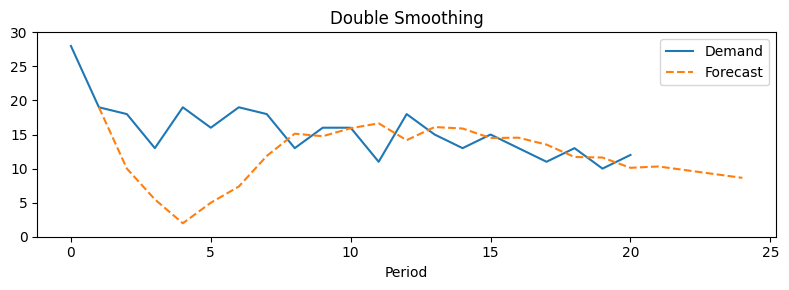

In [22]:
d = [28,19,18,13,19,16,19,18,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = double_exp_smooth(d, alpha=0.4, beta=0.4, extra_periods=4)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Double Smoothing',ylim=(0,30),style=['-','--'])
plt.tight_layout()

Check out what we did!

In [5]:
df

,Demand,Forecast,Level,Trend,Error
Period,,,,,
0,28.0,NaN,28.000000,-9.000000,NaN
1,19.0,19.000000,19.000000,-9.000000,0.000000
2,18.0,10.000000,13.200000,-7.720000,8.000000
3,13.0,5.480000,8.488000,-6.516800,7.520000
4,19.0,1.971200,8.782720,-3.792192,17.028800
5,16.0,4.990528,9.394317,-2.030676,11.009472
6,19.0,7.363640,12.018184,-0.168859,11.636360
7,18.0,11.849325,14.309595,0.815249,6.150675
8,13.0,15.124844,14.274907,0.475274,-2.124844


## 🦾 On your own: can you find the optimal values of alpha and beta that minimize error?

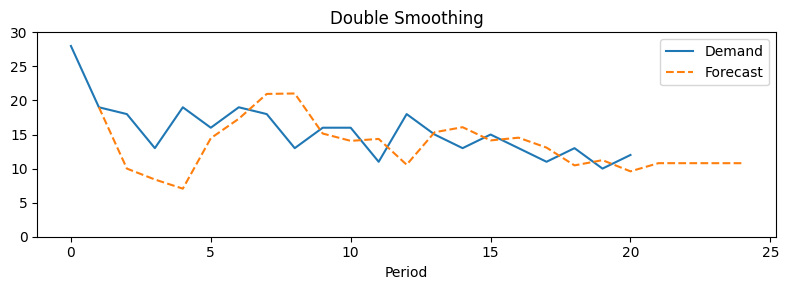

In [26]:
d = [28,19,18,13,19,16,19,18,13,16,16,11,18,15,13,15,13,11,13,10,12]
df = double_exp_smooth(d, alpha=0.5, beta=0.85, extra_periods=4)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Double Smoothing',ylim=(0,30),style=['-','--'])
plt.tight_layout()

## 🦾 On your own: evaluate the model with metrics, scatterplots, line plots and histograms of error

## 🦾 Test on data from the spreadsheet
You should get the same answers!

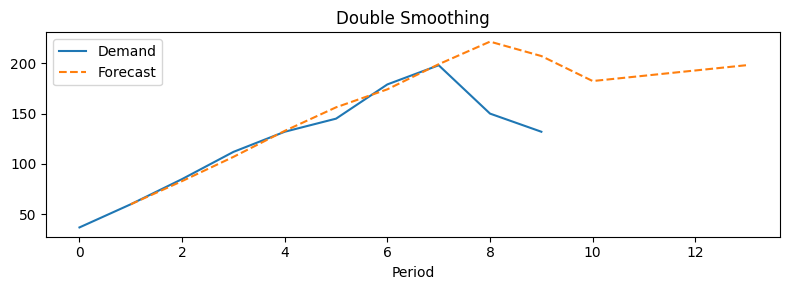

In [27]:
d = [37, 60, 85, 112, 132, 145, 179, 198, 150, 132]


df = double_exp_smooth(d, alpha=0.4, beta=0.3, extra_periods=4)
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Double Smoothing',style=['-','--'])
plt.tight_layout()

## 🦾 'Break' the model by extrapolating too much

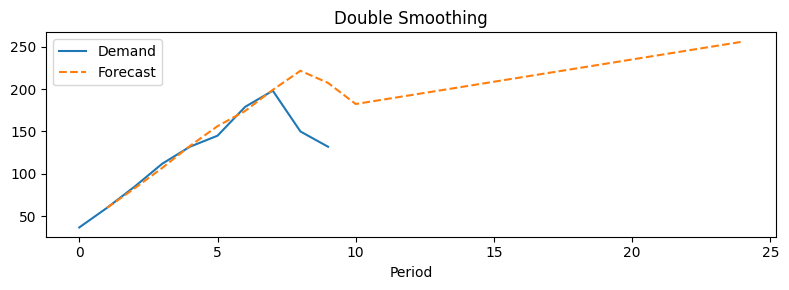

In [20]:
d = [37, 60, 85, 112, 132, 145, 179, 198, 150, 132]


df = double_exp_smooth(d, alpha=0.4, beta=0.3, extra_periods=15) # extra periods = 15 ... does this look reasonable?
df.index.name = 'Period'
df[['Demand','Forecast']].plot(figsize=(8,3),title='Double Smoothing - too much extrapolation',style=['-','--'])
plt.tight_layout()

In [28]:
df

,Demand,Forecast,Level,Trend,Error
Period,,,,,
0,37.0,NaN,37.000000,23.000000,NaN
1,60.0,60.000000,60.000000,23.000000,0.000000
2,85.0,83.000000,83.800000,23.240000,2.000000
3,112.0,107.040000,109.024000,23.835200,4.960000
4,132.0,132.859200,132.515520,23.732096,-0.859200
5,145.0,156.247616,151.748570,22.382382,-11.247616
6,179.0,174.130952,176.078571,22.966668,4.869048
7,198.0,199.045239,198.627143,22.841239,-1.045239
8,150.0,221.468383,192.881030,14.265033,-71.468383
